# Machine Learning Experiment Number 5



**Name:** Om Milind Retharekar   
           
**Roll no.:** CS46

**Class:** BE CSE

**Batch:** CS03

### Aim : To implement a Bagging (Bootstrap Aggregating) ensemble classifier from scratch using Python, apply it to the Pima Indians Diabetes Database, and evaluate its performance against a single base classifier (Decision Tree)**.


## Objectives

1. Understand Ensemble Learning Principles: Comprehend how combining the predictions of multiple diverse models reduces overall model variance.
2. Master Bootstrapping: Implement random resampling of data with replacement from scratch to generate distinct training subsets.
3. Develop a Voting System: Build an aggregation mechanism (Majority Voting) from scratch to consolidate predictions.
4. Learn Baseline Evaluation: Compare the performance of a high-variance, low-bias single decision tree against the more stable Bagging ensemble.
5. Analyze Performance Metrics: Calculate and visualize classification metrics, including a Confusion Matrix, Accuracy, Precision, Recall, and ROC-AUC curve.


Relevant Theory
Ensemble Methods and Bagging
Ensemble learning combines several individual classifiers (base learners) to produce a unified model that generalizes better than any single model on unseen data. Bootstrap Aggregating (Bagging) is a parallel ensemble method designed primarily to reduce variance. High-variance models—such as deep, fully-grown decision trees—are highly sensitive to small changes in their training datasets. Bagging addresses this by smoothing out individual model errors without increasing bias.

The two core components of Bagging are:

1. Bootstrapping (Sampling with Replacement): For a training set of size $N$, we generate $B$ new datasets of the same size $N$. Each instance is selected at random from the original dataset with replacement. This means a single instance can be selected multiple times, while on average, only about 63.2% of the unique training samples are captured in each bootstrap, leaving the rest as out-of-bag (OOB) samples.
2. Aggregating (Majority Voting): A separate base learner $h_b(x)$ is trained independently on each bootstrap sample. For classification, predictions are aggregated by passing a test sample to all $B$ models and taking a majority vote: $$\hat{G}{\text{bag}}(x) = \text{argmax}{k} \sum_{b=1}^{B} I(h_b(x) = k)$$

An alternative to standard Bagging is subagging (subsample aggregating), where smaller training subsets (often $N/2$) are drawn without replacement to reduce correlation and accelerate computation.

---
## Software Requirements

- **Language:** Python 3.x

- **Core Libraries:**
  - **NumPy** for matrix manipulation and custom bootstrapping operations.
  - **Pandas** for loading, indexing, and cleaning tabular data.
  - **Matplotlib / Seaborn** for exploratory scatter plots, bar charts, and performance visualization.
  - **Scikit-learn** for train-test splitting, training individual base decision trees, and comparison with built-in Bagging algorithms.

---

## Dataset Information

The experiment utilizes the **Pima Indians Diabetes Database** from the UCI Machine Learning Repository. The dataset contains medical details for 768 female Pima Indian patients living in Arizona, categorized as either diabetic or non-diabetic.

- **Total Instances:** 768

- **Features (8 predictor variables):**
  1. **`Pregnancies`**: Number of times pregnant.
  2. **`Glucose`**: Plasma glucose concentration over 2 hours in an oral glucose tolerance test.
  3. **`BloodPressure`**: Diastolic blood pressure (mm Hg).
  4. **`SkinThickness`**: Triceps skin fold thickness (mm).
  5. **`Insulin`**: 2-Hour serum insulin ($\mu$U/ml).
  6. **`BMI`**: Body mass index (weight in kg/m$^2$).
  7. **`DiabetesPedigreeFunction`**: A function representing genetic predisposition.
  8. **`Age`**: Age of the subject in years.

- **Target Label (9th column):** **`Outcome`**
  - **0** represents non-diabetic.
  - **1** represents diabetic.

## Experimental Tasks

### Task 1: Environment Setup and Dataset Acquisition

Use dataset using the link  
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

**Goal:** Set up the workspace and load the data.

**Instructions:**

1. Import the necessary modules: **`numpy`**, **`pandas`**, **`matplotlib.pyplot`**, and **`sklearn`**.

2. Load the file **`pima-indians-diabetes.data`** into a Pandas DataFrame, assigning appropriate column headers.

3. Print the following:
   - First five records of the dataset.
   - Dataset shape, expected to be $768 \times 9$.
   - Data types of all features.
   - Descriptive statistics of the numeric features.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

# Load the dataset
columns = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age',
    'Outcome'
]

df = pd.read_csv('diabetes.csv', names=columns, header=0)

# Print the first five records
print("First five records:")
print(df.head())

# Print the dataset shape
print("\nDataset Shape:")
print(df.shape)

# Print data types of all features
print("\nData Types:")
print(df.dtypes)

# Print descriptive statistics of numeric features
print("\nDescriptive Statistics:")
print(df.describe())

First five records:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148           72.0             35    169.5  33.6   
1            1       85           66.0             29    102.5  26.6   
2            8      183           64.0             32    169.5  23.3   
3            1       89           66.0             23     94.0  28.1   
4            0      137           40.0             35    168.0  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Shape:
(768, 9)

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure               float64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    f

## Task 2: Exploratory Data Analysis (EDA)

**Goal:** Visually inspect feature distributions and class balance.

**Instructions:**

1. Calculate the **absolute count** and **percentage** of diabetic (`Outcome = 1`) and non-diabetic (`Outcome = 0`) cases. Plot the class balance using a **bar chart**.

2. Create a **scatter plot** of **`Age`** (Feature 7) against **`Glucose`** (Feature 1), color-coded according to the target variable **`Outcome`**.

3. Briefly explain why a simple linear decision boundary is insufficient to clearly separate the diabetic and non-diabetic classes.

Class Counts:
Outcome
0    500
1    268
Name: count, dtype: int64

Class Percentages:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


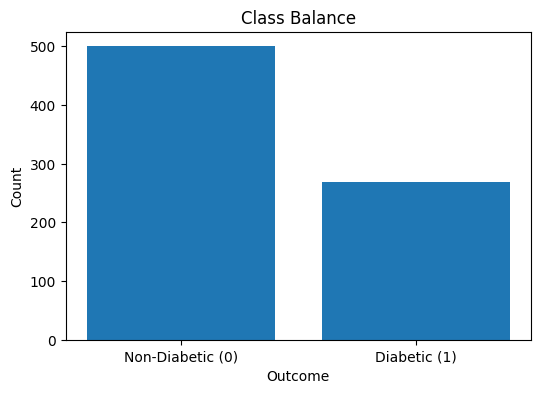

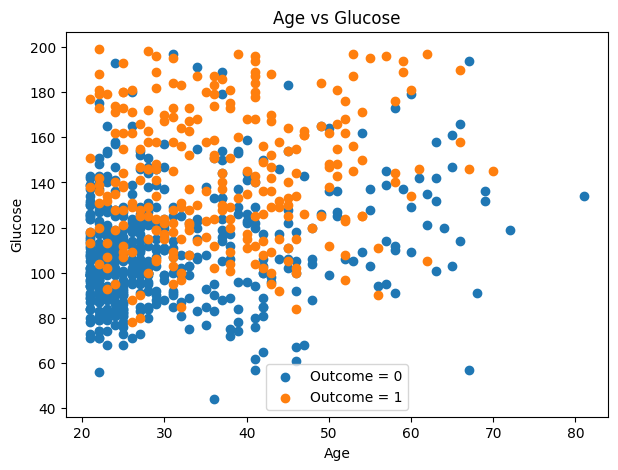

In [2]:
# Calculate absolute count and percentage of each class
class_count = df['Outcome'].value_counts().sort_index()
class_percentage = df['Outcome'].value_counts(normalize=True).sort_index() * 100

print("Class Counts:")
print(class_count)

print("\nClass Percentages:")
print(class_percentage)

# Plot class balance
plt.figure(figsize=(6, 4))
plt.bar(['Non-Diabetic (0)', 'Diabetic (1)'], class_count.values)
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.title('Class Balance')
plt.show()

# Scatter plot of Age against Glucose
plt.figure(figsize=(7, 5))

for outcome in [0, 1]:
    data = df[df['Outcome'] == outcome]
    plt.scatter(data['Age'], data['Glucose'], label=f'Outcome = {outcome}')

plt.xlabel('Age')
plt.ylabel('Glucose')
plt.title('Age vs Glucose')
plt.legend()
plt.show()

**Explanation:**
A simple linear decision boundary is insufficient because the diabetic and non-diabetic observations overlap across different combinations of Age and Glucose. Therefore, a single straight line cannot clearly separate the two classes.

#### **Task 3: Preprocessing and Handling Missing Values**

**Goal:** Handle anomalies and prepare numerical features for further analysis.

**Instructions:**

1. Identify the features where a value of \(0\) is physically impossible:
   \[
   \{\text{Glucose},\text{BloodPressure},\text{SkinThickness},
   \text{Insulin},\text{BMI}\}
   \]

2. Replace all invalid \(0\) values in these features with \(\mathrm{NaN}\).

3. Handle the resulting missing values by:
   - imputing them using the **mean** or **median** of the respective feature, or
   - dropping rows containing missing values to maintain numerical consistency.

In [4]:
# Features where 0 is physically impossible
invalid_features = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Replace invalid 0 values with NaN
df[invalid_features] = df[invalid_features].replace(0, np.nan)

# Impute missing values using the median of each respective feature
df[invalid_features] = df[invalid_features].fillna(df[invalid_features].median())

#### **Task 4: Stratified Train-Test Splitting**

**Goal:** Divide the data while preserving class proportions.

**Instructions:**

1. Isolate the feature matrix \(X\) and the target vector \(y\):
   \[
   X = \text{first 8 columns}
   \]
   \[
   y = \text{9th column}
   \]

2. Split the dataset into:
   \[
   \text{Training Data} = 80\%
   \]
   \[
   \text{Test Data} = 20\%
   \]

   Use **stratified sampling** to ensure that the class proportions in the target variable \(y\) are preserved in both the training and test datasets.

In [5]:
from sklearn.model_selection import train_test_split

# Isolate features and target
X = df.iloc[:, :8]
y = df.iloc[:, 8]

# Stratified 80-20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

#### **Task 5: Custom Bootstrap Sampling Function**

**Goal:** Implement the sampling-with-replacement mechanism.

**Instructions:**

1. Write a custom Python function \(\texttt{get\_bootstrap\_sample}(X, y)\) using NumPy's random generation tools, such as:
   \[
   \texttt{np.random.choice}
   \quad \text{or} \quad
   \texttt{np.random.randint}
   \]

2. The function must return a resampled feature matrix \(X^*\) and target vector \(y^*\) of the same size \(N\) as the training set:
   \[
   |X^*| = |y^*| = N
   \]
   
   Sampling should be performed **with replacement**, allowing duplicate rows to appear in the bootstrap sample.

3. Verify that the function works correctly by demonstrating that:
   - Some original row indices are **duplicated** in the bootstrap sample.
   - Some original row indices are **omitted**, forming the **Out-of-Bag (OOB)** samples.

In [9]:
# Custom bootstrap sampling function
def get_bootstrap_sample(X, y):
    N = len(X)
    indices = np.random.randint(0, N, size=N)

    X_bootstrap = X.iloc[indices]
    y_bootstrap = y.iloc[indices]

    return X_bootstrap, y_bootstrap, indices

# Generate a bootstrap sample
X_bootstrap, y_bootstrap, bootstrap_indices = get_bootstrap_sample(X_train, y_train)

# Identify duplicated and OOB indices
unique_indices, counts = np.unique(bootstrap_indices, return_counts=True)

duplicated_indices = unique_indices[counts > 1]
oob_indices = np.setdiff1d(np.arange(len(X_train)), unique_indices)

# Display verification in a neat format
print("========== Bootstrap Sampling Verification ==========")
print(f"Original training set size : {len(X_train)}")
print(f"Bootstrap sample size      : {len(X_bootstrap)}")
print(f"Duplicated indices count   : {len(duplicated_indices)}")
print(f"OOB samples count          : {len(oob_indices)}")

print("\n---------- Duplicated Indices ----------")
print(duplicated_indices)

print("\n---------- OOB Indices ----------")
print(oob_indices)

========== Bootstrap Sampling Verification ==========
Original training set size : 614
Bootstrap sample size      : 614
Duplicated indices count   : 166
OOB samples count          : 223

---------- Duplicated Indices ----------
[  0   1  12  21  24  25  29  32  33  38  41  48  51  52  57  60  64  67
  75  76  77  78  79  94  98 100 102 104 107 112 115 116 128 131 136 146
 147 151 157 158 160 164 167 168 181 187 193 195 196 200 201 204 208 213
 216 223 224 230 236 239 240 248 250 256 261 262 272 275 282 285 288 290
 296 298 302 310 311 312 313 314 316 319 320 324 325 326 333 341 342 346
 349 350 355 360 362 368 371 384 392 399 400 406 407 410 412 416 418 422
 424 427 430 431 432 433 434 438 442 443 447 448 452 455 461 462 463 473
 484 485 487 492 497 498 503 511 512 513 514 517 528 530 536 537 541 551
 561 563 564 565 572 575 584 585 592 594 595 596 597 598 599 601 603 604
 605 611 612 613]

---------- OOB Indices ----------
[  2   3   5   7   8  11  16  20  27  30  31  34  35  37  39  

#### **Task 6: Growing the Ensemble of Base Classifiers**

**Goal:** Programmatically train diverse base learners.

**Instructions:**

1. Initialize an empty list to store the trained models and choose the number of bootstrap iterations, for example:
   \[
   B = 50
   \]

2. Execute the following steps for \(B\) iterations:

   - Generate a unique bootstrap training dataset:
     \[
     (X^{*b}, y^{*b})
     \]
     using the bootstrap sampling function from **Task 5**.

   - Instantiate a Scikit-Learn `DecisionTreeClassifier` with:
     \[
     \texttt{max\_depth=None}
     \]
     This ensures that the decision trees are **fully grown**, resulting in high-variance base learners.

   - Fit the decision tree on the bootstrapped training subset:
     \[
     \text{Model}_b.fit(X^{*b}, y^{*b})
     \]

   - Append the trained model to the ensemble list.

3. After completing all \(B\) iterations, the ensemble should contain:
   \[
   B = 50
   \]
   independently trained decision trees.

In [10]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the ensemble
B = 50
ensemble = []

# Train B decision trees on unique bootstrap samples
for b in range(B):
    X_bootstrap, y_bootstrap, _ = get_bootstrap_sample(X_train, y_train)

    model = DecisionTreeClassifier(max_depth=None)
    model.fit(X_bootstrap, y_bootstrap)

    ensemble.append(model)

print("Number of trained decision trees:", len(ensemble))

Number of trained decision trees: 50


#### **Task 7: Implementing Aggregation (Majority Voting) from Scratch**

**Goal:** Consolidate individual model decisions using majority voting.

**Instructions:**

1. Write a custom function:
   \[
   \texttt{custom\_bagging\_predict(ensemble, X\_test)}
   \]
   to generate the final predictions.

2. For each sample in \(X_{\text{test}}\), collect the predictions generated by all \(B\) decision trees in the ensemble:
   \[
   \hat{y}_1,\hat{y}_2,\ldots,\hat{y}_B
   \]

3. Apply a **majority voting** rule to determine the final predicted class. The class with the highest number of votes is selected:
   \[
   \hat{y} =
   \underset{c \in \{0,1\}}{\arg\max}
   \sum_{b=1}^{B} I(\hat{y}_b=c)
   \]

   where \(I(\cdot)\) is an indicator function.

4. The final prediction for each test sample must therefore be either:
   \[
   \hat{y} \in \{0,1\}
   \]

5. The function should return the final majority-voted predictions for all samples in \(X_{\text{test}}\).

In [11]:
# Custom majority voting function
def custom_bagging_predict(ensemble, X_test):
    predictions = np.array([model.predict(X_test) for model in ensemble])

    final_predictions = np.apply_along_axis(
        lambda x: np.bincount(x.astype(int)).argmax(),
        axis=0,
        arr=predictions
    )

    return final_predictions

# Generate majority-voted predictions
y_pred_bagging = custom_bagging_predict(ensemble, X_test)

print("Bagging predictions:")
print(y_pred_bagging)

Bagging predictions:
[0 0 0 1 0 0 1 1 0 1 0 1 0 0 1 1 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 0 0 0 1 1 0
 0 1 0 0 0 0 1 0 1 1 0 1 1 0 1 1 0 0 0 1 0 1 0 1 0 0 1 0 0 1 0 0 1 0 0 0 1
 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0
 1 1 1 0 0 1 0 1 0 1 0 0 1 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 1 1
 0 0 0 0 1 0]


#### **Task 8: Single Classifier vs. Bagging Performance Comparison**

- **Goal:** Observe the variance-reduction benefits of ensembling.

- **Instructions:**
  1. Train a standalone, single \(\texttt{DecisionTreeClassifier}\) (fully grown, no depth limit) on the original, un-resampled training data.
  2. Predict the classes for \(X_{\text{test}}\) using both the single tree and your custom Bagging classifier.
  3. Construct a **Confusion Matrix** for both models.
  4. Compute and print **Accuracy, Precision, Recall, and F1-Score** for both models, demonstrating how Bagging stabilizes results and reduces error rates.

In [12]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Train a standalone fully grown decision tree
single_tree = DecisionTreeClassifier(max_depth=None)
single_tree.fit(X_train, y_train)

# Predict using the single tree
y_pred_single = single_tree.predict(X_test)

# Predict using the custom Bagging classifier
y_pred_bagging = custom_bagging_predict(ensemble, X_test)

# Confusion matrices
cm_single = confusion_matrix(y_test, y_pred_single)
cm_bagging = confusion_matrix(y_test, y_pred_bagging)

print("Confusion Matrix - Single Decision Tree:")
print(cm_single)

print("\nConfusion Matrix - Bagging:")
print(cm_bagging)

# Performance metrics
print("\nSingle Decision Tree Performance:")
print("Accuracy :", accuracy_score(y_test, y_pred_single))
print("Precision:", precision_score(y_test, y_pred_single))
print("Recall   :", recall_score(y_test, y_pred_single))
print("F1-Score :", f1_score(y_test, y_pred_single))

print("\nBagging Performance:")
print("Accuracy :", accuracy_score(y_test, y_pred_bagging))
print("Precision:", precision_score(y_test, y_pred_bagging))
print("Recall   :", recall_score(y_test, y_pred_bagging))
print("F1-Score :", f1_score(y_test, y_pred_bagging))

Confusion Matrix - Single Decision Tree:
[[87 13]
 [16 38]]

Confusion Matrix - Bagging:
[[93  7]
 [10 44]]

Single Decision Tree Performance:
Accuracy : 0.8116883116883117
Precision: 0.7450980392156863
Recall   : 0.7037037037037037
F1-Score : 0.7238095238095238

Bagging Performance:
Accuracy : 0.8896103896103896
Precision: 0.8627450980392157
Recall   : 0.8148148148148148
F1-Score : 0.8380952380952381


#### **Task 9: ROC-AUC Analysis and Curve Visualization**

- **Goal:** Measure classification performance at different thresholds.

- **Instructions:**
  1. Calculate predicted class probabilities by averaging the probability estimates (\(\texttt{predict\_proba}\)) across all \(B\) decision trees in your custom Bagging model.
  2. Plot the **Receiver Operating Characteristic (ROC) curve** for both the single decision tree and the custom Bagging model on a single chart.
  3. Compute and contrast the **Area Under the Curve (AUC)** for both configurations, noting the improvement.

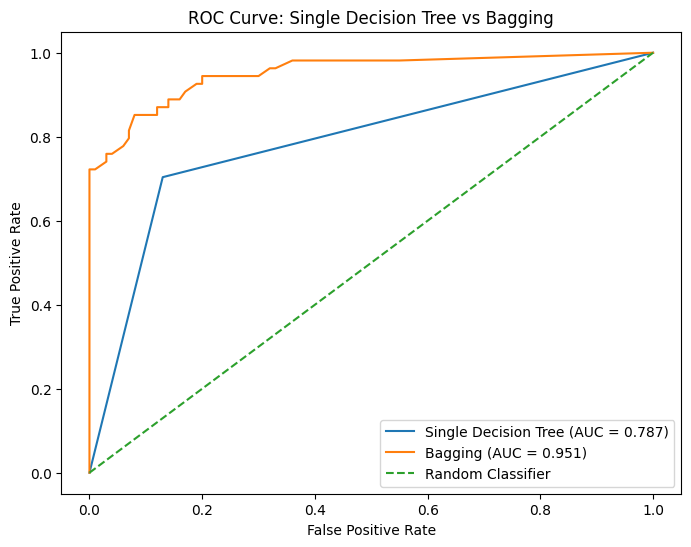

Single Decision Tree AUC: 0.7868518518518519
Bagging AUC: 0.9514814814814814


In [15]:
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate average predicted probabilities for the Bagging model
bagging_probabilities = np.mean(
    [model.predict_proba(X_test)[:, 1] for model in ensemble],
    axis=0
)

# Calculate predicted probabilities for the single decision tree
single_tree_probabilities = single_tree.predict_proba(X_test)[:, 1]

# Calculate ROC curve values
fpr_single, tpr_single, _ = roc_curve(y_test, single_tree_probabilities)
fpr_bagging, tpr_bagging, _ = roc_curve(y_test, bagging_probabilities)

# Calculate AUC
auc_single = roc_auc_score(y_test, single_tree_probabilities)
auc_bagging = roc_auc_score(y_test, bagging_probabilities)

# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_single, tpr_single, label=f'Single Decision Tree (AUC = {auc_single:.3f})')
plt.plot(fpr_bagging, tpr_bagging, label=f'Bagging (AUC = {auc_bagging:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Single Decision Tree vs Bagging')
plt.legend()
plt.show()

# Print AUC values
print("Single Decision Tree AUC:", auc_single)
print("Bagging AUC:", auc_bagging)

#### **Task 10: Validation against Scikit-Learn's BaggingClassifier**

- **Goal:** Verify custom code correctness.

- **Instructions:**
  1. Instantiate Scikit-Learn's built-in \(\texttt{BaggingClassifier}\) using \(\texttt{DecisionTreeClassifier(max\_depth=None)}\) as the base estimator and \(\texttt{n\_estimators=50}\).
  2. Fit the classifier on the training set and evaluate it on the test set.
  3. Compare the resulting test accuracy and confusion matrix against your custom implementation from **Task 7** and **Task 8** to validate your custom bootstrap and aggregation logic.

In [16]:
from sklearn.ensemble import BaggingClassifier

# Create the built-in BaggingClassifier
sklearn_bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=None),
    n_estimators=50,
    random_state=42
)

# Fit the classifier on the training set
sklearn_bagging.fit(X_train, y_train)

# Predict on the test set
y_pred_sklearn = sklearn_bagging.predict(X_test)

# Calculate accuracy
sklearn_accuracy = accuracy_score(y_test, y_pred_sklearn)

# Calculate confusion matrix
sklearn_cm = confusion_matrix(y_test, y_pred_sklearn)

# Compare results
print("Custom Bagging Accuracy:", accuracy_score(y_test, y_pred_bagging))
print("Scikit-Learn Bagging Accuracy:", sklearn_accuracy)

print("\nCustom Bagging Confusion Matrix:")
print(cm_bagging)

print("\nScikit-Learn Bagging Confusion Matrix:")
print(sklearn_cm)

Custom Bagging Accuracy: 0.8896103896103896
Scikit-Learn Bagging Accuracy: 0.8831168831168831

Custom Bagging Confusion Matrix:
[[93  7]
 [10 44]]

Scikit-Learn Bagging Confusion Matrix:
[[91  9]
 [ 9 45]]


### **Conclusion and Interpretation**

Students should summarize their findings by answering the following key questions:

1. **Variance and Stability:** How does the test accuracy of the Bagging ensemble compare to the single decision tree? Why does Bagging provide more consistent performance across different train-test splits?

2. **Wisdom of Crowds:** How does random resampling with replacement (bootstrapping) foster model diversity, and how does the consensus voting rule translate to a "Wisdom of Crowds" effect?

3. **Clinical Interpretation:** In predicting diabetes, why are False Negatives (predicting non-diabetic for a diabetic patient) especially costly, and how does Bagging's Recall metric help minimize this risk compared to a single decision tree?